# AIDev Project 2 — Exploration Notebook

### 1. Imports and config

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

# Hugging Face base path — pandas can read parquet directly from here
HF_BASE = 'hf://datasets/hao-li/AIDev/'

print('Setup complete.')

Setup complete.


### 2. Load AIDev-pop tables
`pull_request`, `pr_reviews`, `pr_comments`.

In [28]:
# Load AIDev-pop pull request table
pr_df = pd.read_parquet(HF_BASE + 'pull_request.parquet')
print(f'pull_request shape: {pr_df.shape}')
print(f'columns: {list(pr_df.columns)}')
pr_df.head(3)

pull_request shape: (33596, 14)
columns: ['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url']


,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url
0,3264933329,2911,Fix: Wait for all partitions in load_collectio...,## Summary\n\nFixes an issue where `load_colle...,Claude_Code,108661493,weiliu1031,closed,2025-07-26T02:59:01Z,2025-07-29T07:01:20Z,None,191751505,https://api.github.com/repos/milvus-io/pymilvus,https://github.com/milvus-io/pymilvus/pull/2911
1,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,Claude_Code,61827001,cm-kojimat,closed,2025-07-26T04:56:55Z,2025-07-26T22:12:24Z,2025-07-26T22:12:24Z,1025472321,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2
2,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26T13:31:19Z,2025-07-26T13:37:22Z,2025-07-26T13:37:22Z,988488798,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30


In [29]:
# Reviews table
reviews_df = pd.read_parquet(HF_BASE + 'pr_reviews.parquet')
print(f'pr_reviews shape: {reviews_df.shape}')
print(f'columns: {list(reviews_df.columns)}')
reviews_df.head(3)

pr_reviews shape: (28875, 7)
columns: ['id', 'pr_id', 'user', 'user_type', 'state', 'submitted_at', 'body']


,id,pr_id,user,user_type,state,submitted_at,body
0,2885691382,3107321792,coderabbitai[bot],Bot,COMMENTED,2025-06-01T14:22:22Z,**Actionable comments posted: 2**\n\n<details>...
1,2885712797,3107321792,coderabbitai[bot],Bot,COMMENTED,2025-06-01T14:37:45Z,**Actionable comments posted: 1**\n\n<details>...
2,3059587397,3234660269,Fank,User,COMMENTED,2025-07-27T15:06:40Z,None


In [30]:
# Comments table (issue-style PR thread comments)
comments_df = pd.read_parquet(HF_BASE + 'pr_comments.parquet')
print(f'pr_comments shape: {comments_df.shape}')
print(f'columns: {list(comments_df.columns)}')
comments_df.head(3)

pr_comments shape: (39122, 7)
columns: ['id', 'pr_id', 'user', 'user_id', 'user_type', 'created_at', 'body']


,id,pr_id,user,user_id,user_type,created_at,body
0,2927293042,3107321792,coderabbitai[bot],136622811,Bot,2025-06-01T14:15:35Z,<!-- This is an auto-generated comment: summar...
1,3090154270,3234660269,Fank,1900106,User,2025-07-18T17:22:34Z,"claude budget reached, development is on hold ..."
2,2848667986,3037457814,wilsonccccc,6146503,User,2025-05-03T15:12:37Z,"Hi, thanks for sharing and contributing! Pleas..."


In [31]:
# Inline review comments (code-line level) — the substantive review channel,
# distinct from formal reviews (pr_reviews) and PR thread comments (pr_comments).
review_comments_df = pd.read_parquet(HF_BASE + 'pr_review_comments_v2.parquet')
print(f'pr_review_comments_v2 shape: {review_comments_df.shape}')
print(f'columns: {list(review_comments_df.columns)}')
review_comments_df.head(3)

pr_review_comments_v2 shape: (26868, 15)
columns: ['id', 'pull_request_review_id', 'user', 'user_type', 'diff_hunk', 'path', 'position', 'original_position', 'commit_id', 'original_commit_id', 'body', 'pull_request_url', 'created_at', 'updated_at', 'in_reply_to_id']


,id,pull_request_review_id,user,user_type,diff_hunk,path,position,original_position,commit_id,original_commit_id,body,pull_request_url,created_at,updated_at,in_reply_to_id
0,2110791802,2873410389,Copilot,Bot,"@@ -80,4 +81,7 @@ export const giselleEngine =...",apps/studio.giselles.ai/app/giselle-engine.ts,12.0,12,129ddeeabb303c5e20473132b83507120cb4cfc4,6f6b42ee11f2b2b3bdcc855b9871ba48d9be25bc,[nitpick] Consider adding documentation or a c...,https://api.github.com/repos/giselles-ai/gisel...,2025-05-28T03:04:12Z,2025-05-28T03:04:13Z,NaN
1,2200843160,3010483959,dpgeorge,User,"@@ -56,6 +56,14 @@\n #define PHY_SPEED_100FULL...",ports/stm32/eth_phy.h,NaN,4,47bace5680b27e235dc5d06ee5c3adff54079d7d,05231c28d4ac24eac705507ce6b50e6e504e76d0,These constants aren't used anywhere.,https://api.github.com/repos/micropython/micro...,2025-07-11T14:09:34Z,2025-07-11T14:09:34Z,NaN
2,2137612457,2913085976,jurasic-pf,User,"@@ -0,0 +1,294 @@\n+// SPDX-FileCopyrightText:...",src/vmecpp/cpp/vmecpp/vmec/vmec_constants/vmec...,NaN,48,a7797dc5ccbee0541708f452d7b0e63bc6912bf4,e71a34ef0b09bc8994974a5b70d1de8c65d57858,Have we formally decided for/against using spe...,https://api.github.com/repos/proximafusion/vme...,2025-06-10T11:08:27Z,2025-06-10T11:08:28Z,NaN


### 3. Schema summaries
Dtype, null %, unique count, and a sample value per column.

In [32]:
def schema_summary(df, name):
    """Compact schema view: dtype, null count, unique count, sample value."""
    summary = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'nulls': df.isna().sum(),
        'null_pct': (df.isna().mean() * 100).round(1),
        'unique': df.nunique(dropna=True),
        'sample': [df[c].dropna().iloc[0] if df[c].dropna().size else None for c in df.columns]
    })
    print(f'\n=== {name} ({len(df):,} rows) ===')
    return summary

schema_summary(pr_df, 'pull_request')


=== pull_request (33,596 rows) ===


,dtype,nulls,null_pct,unique,sample
id,int64,0,0.0,33596,3264933329
number,int64,0,0.0,13195,2911
title,object,0,0.0,32332,Fix: Wait for all partitions in load_collectio...
body,object,360,1.1,33012,## Summary\n\nFixes an issue where `load_colle...
agent,object,0,0.0,5,Claude_Code
user_id,int64,0,0.0,1797,108661493
user,object,0,0.0,1797,weiliu1031
state,object,0,0.0,2,closed
created_at,object,0,0.0,33437,2025-07-26T02:59:01Z
closed_at,object,2312,6.9,30882,2025-07-29T07:01:20Z


In [33]:
schema_summary(reviews_df, 'pr_reviews')


=== pr_reviews (28,875 rows) ===


,dtype,nulls,null_pct,unique,sample
id,int64,0,0.0,28875,2885691382
pr_id,int64,0,0.0,8140,3107321792
user,object,1,0.0,2535,coderabbitai[bot]
user_type,object,1,0.0,2,Bot
state,object,0,0.0,4,COMMENTED
submitted_at,object,0,0.0,28726,2025-06-01T14:22:22Z
body,object,20934,72.5,6930,**Actionable comments posted: 2**\n\n<details>...


In [34]:
schema_summary(comments_df, 'pr_comments')


=== pr_comments (39,122 rows) ===


,dtype,nulls,null_pct,unique,sample
id,int64,0,0.0,39122,2927293042
pr_id,int64,0,0.0,12975,3107321792
user,object,0,0.0,2353,coderabbitai[bot]
user_id,int64,0,0.0,2353,136622811
user_type,object,0,0.0,2,Bot
created_at,object,0,0.0,38094,2025-06-01T14:15:35Z
body,object,0,0.0,29906,<!-- This is an auto-generated comment: summar...


### 4. Headline counts
Totals for the dataset slide: PRs, agents, repos, reviewers.

In [35]:
# NOTE: column names below assume the standard AIDev schema. If a column isn't found,
# check the schema_summary output above and substitute the correct name.

headline = {
    'Total agent-authored PRs': len(pr_df),
    'Unique agents': pr_df['agent'].nunique() if 'agent' in pr_df.columns else 'check schema',
    'Unique repositories': pr_df['repo_id'].nunique() if 'repo_id' in pr_df.columns else pr_df.get('repository_id', pd.Series()).nunique(),
    'Total formal reviews': len(reviews_df),
    'Unique reviewers': reviews_df['user_id'].nunique() if 'user_id' in reviews_df.columns else 'check schema',
    'Total PR thread comments': len(comments_df),
}

for k, v in headline.items():
    print(f'{k:35s}: {v:,}' if isinstance(v, (int, np.integer)) else f'{k:35s}: {v}')

Total agent-authored PRs           : 33,596
Unique agents                      : 5
Unique repositories                : 2,807
Total formal reviews               : 28,875
Unique reviewers                   : check schema
Total PR thread comments           : 39,122


### 5. PRs per agent

agent
OpenAI_Codex    21799
Copilot          4970
Devin            4827
Cursor           1541
Claude_Code       459
Name: count, dtype: int64


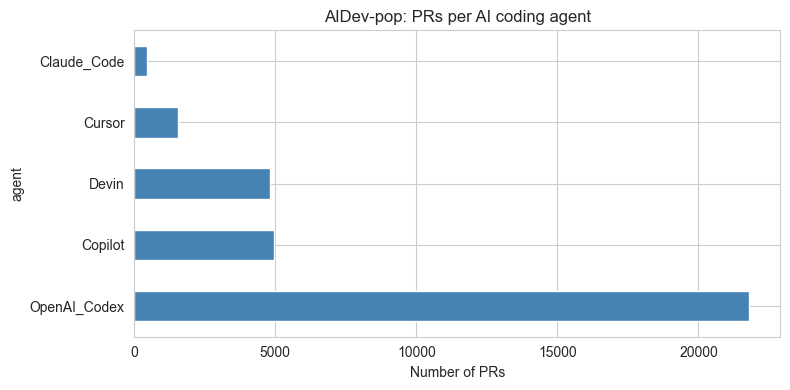

In [36]:
agent_col = 'agent' if 'agent' in pr_df.columns else 'agent_label'  # adjust if needed
agent_counts = pr_df[agent_col].value_counts()
print(agent_counts)

fig, ax = plt.subplots(figsize=(8, 4))
agent_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of PRs')
ax.set_title('AIDev-pop: PRs per AI coding agent')
plt.tight_layout()
plt.savefig('prs_per_agent.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. PR outcomes
Merged / closed / open — overall and by agent.

In [37]:
# GitHub PR state is usually 'open' or 'closed'; merged is a separate boolean.
# Combine into a clean outcome label.
def label_outcome(row):
    if row.get('merged') is True or row.get('merged_at') is not None and pd.notna(row.get('merged_at')):
        return 'merged'
    if row.get('state') == 'closed':
        return 'closed_unmerged'
    return 'open'

# Adjust based on actual columns from schema_summary above
if 'merged_at' in pr_df.columns:
    pr_df['outcome'] = np.where(
        pr_df['merged_at'].notna(), 'merged',
        np.where(pr_df['state'] == 'closed', 'closed_unmerged', 'open')
    )
elif 'merged' in pr_df.columns:
    pr_df['outcome'] = np.where(
        pr_df['merged'] == True, 'merged',
        np.where(pr_df['state'] == 'closed', 'closed_unmerged', 'open')
    )

outcome_counts = pr_df['outcome'].value_counts()
print(outcome_counts)
print(f'\nMerge rate: {outcome_counts.get("merged", 0) / len(pr_df) * 100:.1f}%')

outcome
merged             24014
closed_unmerged     7270
open                2312
Name: count, dtype: int64

Merge rate: 71.5%


outcome       closed_unmerged  merged  open
agent                                      
Claude_Code              23.7    59.0  17.2
Copilot                  35.3    43.0  21.7
Cursor                   22.2    65.2  12.6
Devin                    43.0    53.8   3.2
OpenAI_Codex             13.7    82.6   3.7


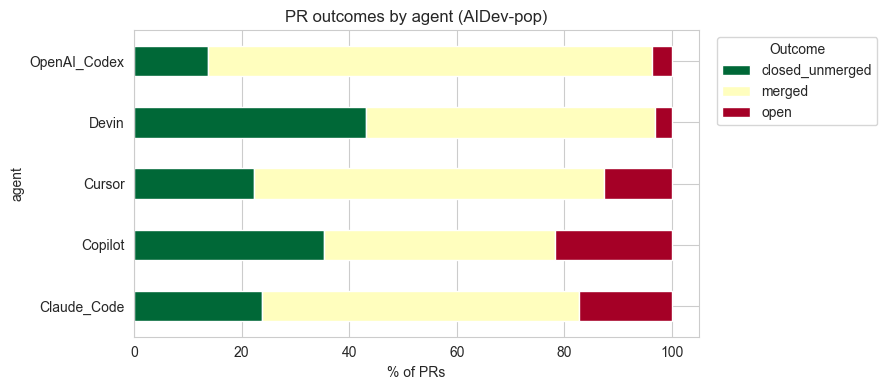

In [38]:
# Outcome by agent — interesting cross-tab
ct = pd.crosstab(pr_df[agent_col], pr_df['outcome'], normalize='index') * 100
print(ct.round(1))

fig, ax = plt.subplots(figsize=(9, 4))
ct.plot(kind='barh', stacked=True, ax=ax, colormap='RdYlGn_r')
ax.set_xlabel('% of PRs')
ax.set_title('PR outcomes by agent (AIDev-pop)')
ax.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('outcomes_by_agent.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Review intensity per PR
Review and comment counts joined onto each PR.

In [39]:
# Reviews and comments use 'pr_id' to point to the PR;
# the PR table uses 'id' as its primary key. Two different keys.
reviews_per_pr = reviews_df.groupby('pr_id').size().rename('n_reviews')
comments_per_pr = comments_df.groupby('pr_id').size().rename('n_comments')

pr_enriched = (
    pr_df.set_index('id')
         .join(reviews_per_pr)
         .join(comments_per_pr)
         .fillna({'n_reviews': 0, 'n_comments': 0})
)
pr_enriched['n_reviews'] = pr_enriched['n_reviews'].astype(int)
pr_enriched['n_comments'] = pr_enriched['n_comments'].astype(int)

# Sanity check — these should both be well above zero
print(f"PRs with at least 1 review:  {(pr_enriched['n_reviews'] > 0).sum():,}")
print(f"PRs with at least 1 comment: {(pr_enriched['n_comments'] > 0).sum():,}")
print(f"\nReviews per PR — descriptive stats:")
print(pr_enriched['n_reviews'].describe().round(2))
print(f"\nComments per PR — descriptive stats:")
print(pr_enriched['n_comments'].describe().round(2))

# What % of PRs receive zero formal reviews? Zero comments?
print(f"\nPRs with 0 formal reviews:   {(pr_enriched['n_reviews'] == 0).mean() * 100:.1f}%")
print(f"PRs with 0 thread comments:  {(pr_enriched['n_comments'] == 0).mean() * 100:.1f}%")

PRs with at least 1 review:  8,140
PRs with at least 1 comment: 12,975

Reviews per PR — descriptive stats:
count    33596.00
mean         0.86
std          2.78
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         30.00
Name: n_reviews, dtype: float64

Comments per PR — descriptive stats:
count    33596.00
mean         1.16
std          2.45
min          0.00
25%          0.00
50%          0.00
75%          2.00
max         30.00
Name: n_comments, dtype: float64

PRs with 0 formal reviews:   75.8%
PRs with 0 thread comments:  61.4%


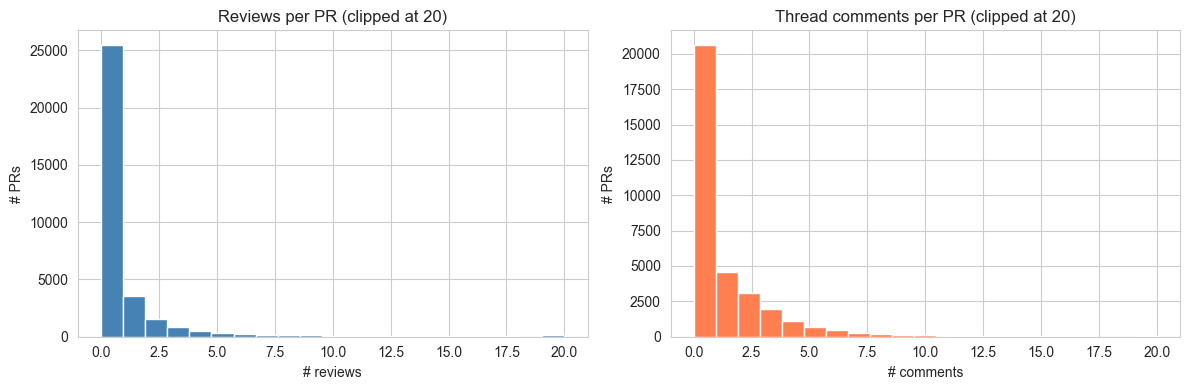

In [40]:
# Distribution plot — log scale because of long tails
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pr_enriched['n_reviews'].clip(upper=20).hist(bins=21, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Reviews per PR (clipped at 20)')
axes[0].set_xlabel('# reviews'); axes[0].set_ylabel('# PRs')

pr_enriched['n_comments'].clip(upper=20).hist(bins=21, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Thread comments per PR (clipped at 20)')
axes[1].set_xlabel('# comments'); axes[1].set_ylabel('# PRs')

plt.tight_layout()
plt.savefig('review_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

No-review rate by agent
              total_prs  no_review_count  no_review_pct
agent                                                  
OpenAI_Codex      21799            19451           89.2
Claude_Code         459              268           58.4
Devin              4827             2680           55.5
Cursor             1541              769           49.9
Copilot            4970             2288           46.0


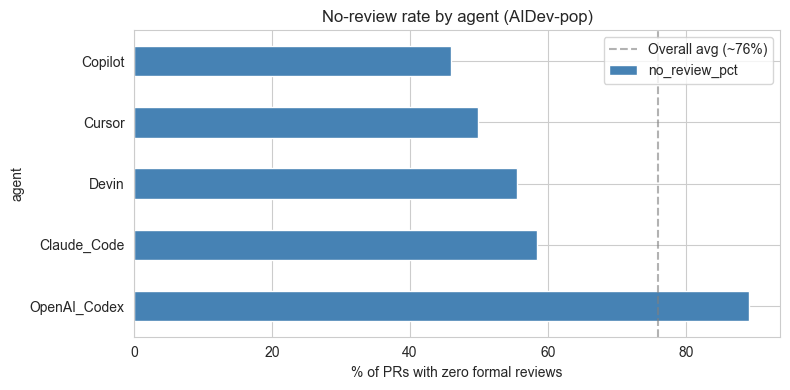

What happens to PRs that receive zero reviews?

Outcome % within each group:
outcome     closed_unmerged  merged  open
no_review                                
No reviews             23.1    71.0   5.8
Reviewed               17.0    72.9  10.1


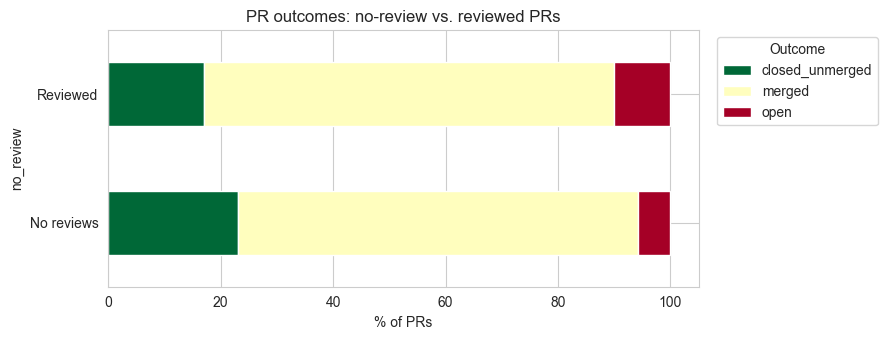

The 'fast lane': PRs merged with no formal review
Fast-lane PRs: 18,082 (53.8% of all PRs)

Fast-lane PRs by agent:
agent
OpenAI_Codex    16174
Devin             971
Cursor            451
Copilot           343
Claude_Code       143
Name: count, dtype: int64

% of each agent's PRs that hit the fast lane:
agent
OpenAI_Codex    74.2
Claude_Code     31.2
Cursor          29.3
Devin           20.1
Copilot          6.9
Name: fast, dtype: float64


In [41]:
print("No-review rate by agent")
print("=" * 60)

no_review_by_agent = (
    pr_enriched.assign(no_review=(pr_enriched['n_reviews'] == 0))
               .groupby('agent')
               .agg(
                   total_prs=('no_review', 'size'),
                   no_review_count=('no_review', 'sum'),
                   no_review_pct=('no_review', 'mean')
               )
)
no_review_by_agent['no_review_pct'] = (no_review_by_agent['no_review_pct'] * 100).round(1)
no_review_by_agent = no_review_by_agent.sort_values('no_review_pct', ascending=False)
print(no_review_by_agent)

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
no_review_by_agent['no_review_pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% of PRs with zero formal reviews')
ax.set_title('No-review rate by agent (AIDev-pop)')
ax.axvline(76, color='gray', linestyle='--', alpha=0.6, label='Overall avg (~76%)')
ax.legend()
plt.tight_layout()
plt.savefig('no_review_by_agent.png', dpi=150, bbox_inches='tight')
plt.show()


print("What happens to PRs that receive zero reviews?")
print("=" * 60)

pr_enriched['no_review'] = pr_enriched['n_reviews'] == 0

# Outcome distribution: no-review vs. reviewed PRs
outcome_by_review = pd.crosstab(
    pr_enriched['no_review'].map({True: 'No reviews', False: 'Reviewed'}),
    pr_enriched['outcome'],
    normalize='index'
) * 100
print("\nOutcome % within each group:")
print(outcome_by_review.round(1))

# Visualize
fig, ax = plt.subplots(figsize=(9, 3.5))
outcome_by_review.plot(kind='barh', stacked=True, ax=ax, colormap='RdYlGn_r')
ax.set_xlabel('% of PRs')
ax.set_title('PR outcomes: no-review vs. reviewed PRs')
ax.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('no_review_vs_reviewed_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()


print("The 'fast lane': PRs merged with no formal review")
print("=" * 60)

fast_lane = pr_enriched[(pr_enriched['n_reviews'] == 0) & (pr_enriched['outcome'] == 'merged')]
print(f"Fast-lane PRs: {len(fast_lane):,} ({len(fast_lane) / len(pr_enriched) * 100:.1f}% of all PRs)")
print(f"\nFast-lane PRs by agent:")
print(fast_lane['agent'].value_counts())

# Fast-lane share within each agent
fast_lane_pct = (
    pr_enriched.assign(fast=(pr_enriched['n_reviews'] == 0) & (pr_enriched['outcome'] == 'merged'))
               .groupby('agent')['fast'].mean() * 100
).round(1).sort_values(ascending=False)
print(f"\n% of each agent's PRs that hit the fast lane:")
print(fast_lane_pct)

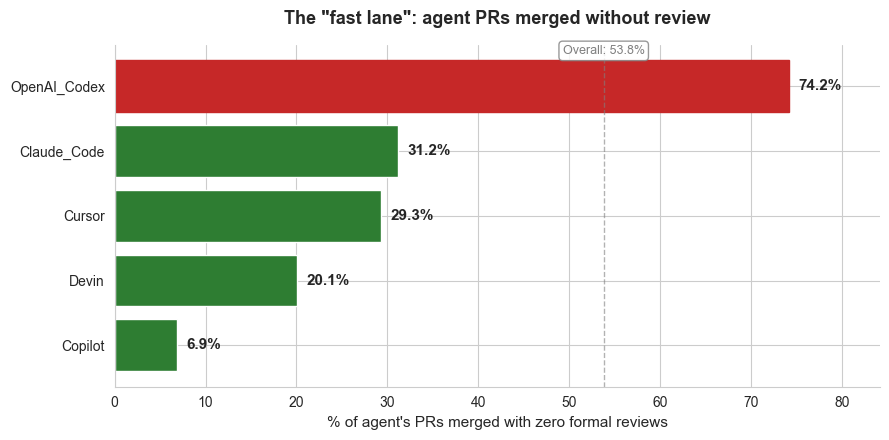

Saved fast_lane_by_agent.png


In [42]:
fast_lane_pct = (
    pr_enriched.assign(fast=(pr_enriched['n_reviews'] == 0) & (pr_enriched['outcome'] == 'merged'))
               .groupby('agent')['fast'].mean() * 100
).round(1).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(fast_lane_pct.index, fast_lane_pct.values, color='#2E7D32', edgecolor='white')

# Highlight Codex in a distinct color since it's the standout
for bar, agent in zip(bars, fast_lane_pct.index):
    if agent == 'OpenAI_Codex':
        bar.set_color('#C62828')

# Value labels at the end of each bar
for bar, val in zip(bars, fast_lane_pct.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontsize=11, fontweight='bold')

# Reference line at the dataset-wide average (53.8%)
ax.axvline(53.8, color='gray', linestyle='--', alpha=0.6, linewidth=1)
ax.text(53.8, 4.5, 'Overall: 53.8%', color='gray', fontsize=9, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

ax.set_xlabel('% of agent\'s PRs merged with zero formal reviews', fontsize=11)
ax.set_title('The "fast lane": agent PRs merged without review',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, max(fast_lane_pct.values) + 10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fast_lane_by_agent.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved fast_lane_by_agent.png')

### 8. Inline-comment engagement — does "no formal review" mean "no engagement"?
Caveat check before the report: many fast-lane PRs may still get inline code-line comments.

In [43]:
# pr_review_comments_v2 has no direct PR column — it links to a REVIEW.
# Chain: comment.pull_request_review_id -> pr_reviews.id -> pr_reviews.pr_id (the PR id)
print("pr_review_comments_v2 columns:", list(review_comments_df.columns))

# Build a review-id -> pr-id lookup, coercing types so the keys actually match.
rev = reviews_df.copy()
rev['id'] = pd.to_numeric(rev['id'], errors='coerce').astype('Int64')
review_to_pr = rev.dropna(subset=['id']).drop_duplicates('id').set_index('id')['pr_id']

rc = review_comments_df.copy()
rc['pull_request_review_id'] = pd.to_numeric(rc['pull_request_review_id'], errors='coerce').astype('Int64')
rc['pr_id'] = rc['pull_request_review_id'].map(review_to_pr)

matched = rc['pr_id'].notna().mean() * 100
print(f"Inline comments mapped to a PR via review id: {matched:.1f}%")

# Fold inline comment counts into the enriched PR table (safe to re-run).
pr_enriched = pr_enriched.drop(columns=['n_inline_comments', 'any_engagement'], errors='ignore')
inline_per_pr = rc.dropna(subset=['pr_id']).groupby('pr_id').size().rename('n_inline_comments')
pr_enriched = pr_enriched.join(inline_per_pr).fillna({'n_inline_comments': 0})
pr_enriched['n_inline_comments'] = pr_enriched['n_inline_comments'].astype(int)

# "Any engagement" = at least one formal review, thread comment, OR inline comment.
pr_enriched['any_engagement'] = (
    (pr_enriched['n_reviews'] > 0)
    | (pr_enriched['n_comments'] > 0)
    | (pr_enriched['n_inline_comments'] > 0)
)

print(f"PRs with >=1 inline review comment: {(pr_enriched['n_inline_comments'] > 0).sum():,}")
print(f"PRs with 0 inline review comments:  {(pr_enriched['n_inline_comments'] == 0).mean() * 100:.1f}%")

pr_review_comments_v2 columns: ['id', 'pull_request_review_id', 'user', 'user_type', 'diff_hunk', 'path', 'position', 'original_position', 'commit_id', 'original_commit_id', 'body', 'pull_request_url', 'created_at', 'updated_at', 'in_reply_to_id']
Inline comments mapped to a PR via review id: 100.0%
PRs with >=1 inline review comment: 4,465
PRs with 0 inline review comments:  86.7%


In [44]:
# How much of the "no review" / fast-lane population is TRULY silent?
no_review_prs = pr_enriched[pr_enriched['n_reviews'] == 0]
fast_lane = pr_enriched[(pr_enriched['n_reviews'] == 0) & (pr_enriched['outcome'] == 'merged')]

for label, sub in [("PRs with ZERO formal reviews", no_review_prs),
                   ("FAST-LANE PRs (no review, merged)", fast_lane)]:
    print(f"{label}: {len(sub):,}")
    print(f"  with a thread comment:         {(sub['n_comments'] > 0).mean() * 100:.1f}%")
    print(f"  with an inline review comment: {(sub['n_inline_comments'] > 0).mean() * 100:.1f}%")
    print(f"  with ANY engagement:           {sub['any_engagement'].mean() * 100:.1f}%")
    print(f"  TRULY silent (none of the three): {(~sub['any_engagement']).mean() * 100:.1f}%\n")

# Truly-silent merge rate by agent — the honest version of the fast-lane claim
silent_by_agent = (
    pr_enriched.assign(silent=(~pr_enriched['any_engagement']) & (pr_enriched['outcome'] == 'merged'))
               .groupby('agent')['silent'].mean() * 100
).round(1).sort_values(ascending=False)
print("% of each agent's PRs merged with NO engagement of any kind:")
print(silent_by_agent)

PRs with ZERO formal reviews: 25,456
  with a thread comment:         25.8%
  with an inline review comment: 0.0%
  with ANY engagement:           25.8%
  TRULY silent (none of the three): 74.2%

FAST-LANE PRs (no review, merged): 18,082
  with a thread comment:         15.8%
  with an inline review comment: 0.0%
  with ANY engagement:           15.8%
  TRULY silent (none of the three): 84.2%

% of each agent's PRs merged with NO engagement of any kind:
agent
OpenAI_Codex    67.9
Claude_Code     21.4
Cursor          12.5
Copilot          2.9
Devin            0.1
Name: silent, dtype: float64


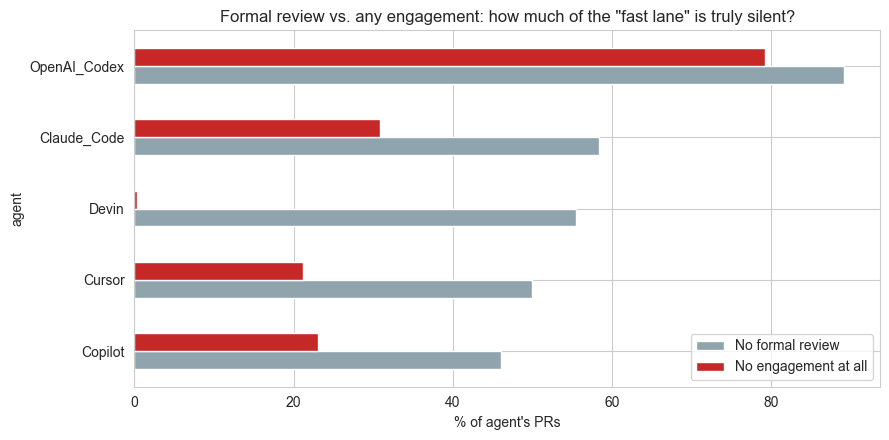

In [45]:
# How much does the "no engagement" picture shrink once inline comments count?
compare = pd.DataFrame({
    'No formal review': (pr_enriched['n_reviews'] == 0).groupby(pr_enriched['agent']).mean() * 100,
    'No engagement at all': (~pr_enriched['any_engagement']).groupby(pr_enriched['agent']).mean() * 100,
}).round(1).sort_values('No formal review', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
compare.plot(kind='barh', ax=ax, color=['#90A4AE', '#C62828'])
ax.set_xlabel("% of agent's PRs")
ax.set_title('Formal review vs. any engagement: how much of the "fast lane" is truly silent?')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('engagement_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()

### 9. Time-to-decision
Hours from PR creation to merge or close, by agent and outcome.

In [46]:
# Compute time-to-decision in hours.
# Adjust column names per the actual schema (created_at, closed_at, merged_at).
for col in ['created_at', 'closed_at', 'merged_at']:
    if col in pr_df.columns:
        pr_df[col] = pd.to_datetime(pr_df[col], errors='coerce', utc=True)

decision_time = pr_df['closed_at'].fillna(pr_df.get('merged_at')) - pr_df['created_at']
pr_df['decision_hours'] = decision_time.dt.total_seconds() / 3600

decided = pr_df[pr_df['outcome'] != 'open'].copy()
print('Time-to-decision (hours), by outcome:')
print(decided.groupby('outcome')['decision_hours'].describe(percentiles=[.25, .5, .75, .9]).round(1))

Time-to-decision (hours), by outcome:
                   count   mean    std  min  25%  50%    75%    90%     max
outcome                                                                    
closed_unmerged   7270.0  109.8  236.1  0.0  0.3  9.3  139.0  278.6  3549.2
merged           24014.0   19.4   94.1  0.0  0.0  0.0    1.1   24.9  1797.7


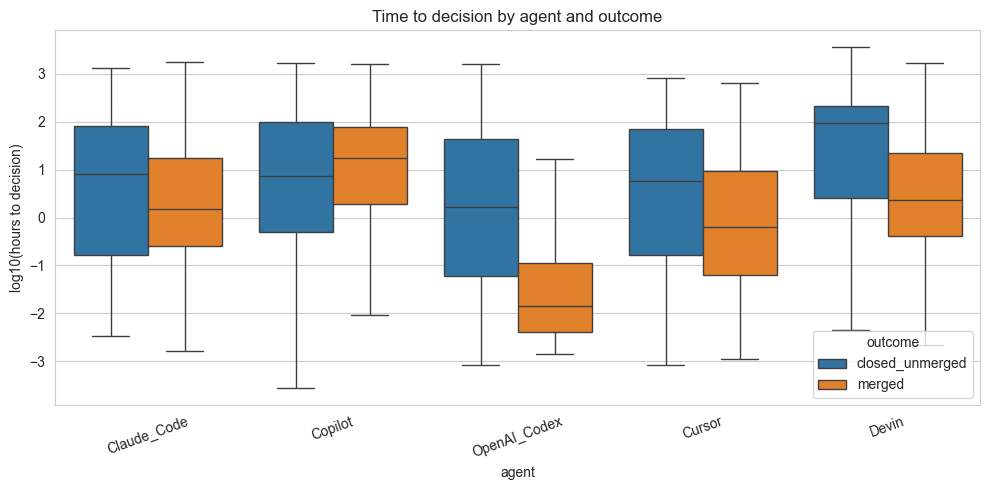

In [47]:
# Visualize: log-scale boxplot of decision time by outcome and agent
plot_df = decided[decided['decision_hours'] > 0].copy()
plot_df['log_hours'] = np.log10(plot_df['decision_hours'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=plot_df, x=agent_col, y='log_hours', hue='outcome', ax=ax, showfliers=False)
ax.set_ylabel('log10(hours to decision)')
ax.set_title('Time to decision by agent and outcome')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('time_to_decision.png', dpi=150, bbox_inches='tight')
plt.show()

### 10. Review verdict mix
Distribution of `APPROVED` / `CHANGES_REQUESTED` / `COMMENTED` / `DISMISSED`.

state
COMMENTED            20431
APPROVED              6499
CHANGES_REQUESTED     1604
DISMISSED              341
Name: count, dtype: int64


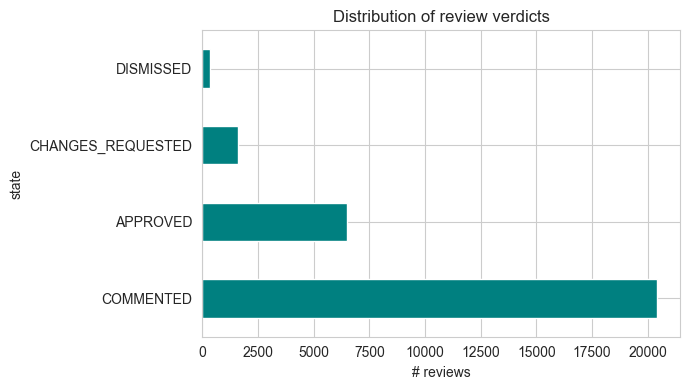

In [48]:
if 'state' in reviews_df.columns:
    verdict_col = 'state'
elif 'review_state' in reviews_df.columns:
    verdict_col = 'review_state'
else:
    verdict_col = None
    print('Check schema_summary for the verdict column name.')

if verdict_col:
    print(reviews_df[verdict_col].value_counts())
    fig, ax = plt.subplots(figsize=(7, 4))
    reviews_df[verdict_col].value_counts().plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Distribution of review verdicts')
    ax.set_xlabel('# reviews')
    plt.tight_layout()
    plt.savefig('review_verdicts.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. RQ2 — reviewer behavior among PRs that DO get evaluated
Scoped to the reviewed subset: review intensity, verdict mix by agent, and review's effect on merge time.

In [49]:
# RQ2 works only on PRs that received at least one formal review.
reviewed = pr_enriched[pr_enriched['n_reviews'] > 0].copy()
print(f"Reviewed PRs: {len(reviewed):,} ({len(reviewed) / len(pr_enriched) * 100:.1f}% of all PRs)\n")
print("Reviews per reviewed PR:")
print(reviewed['n_reviews'].describe(percentiles=[.5, .75, .9]).round(2))
print("\nThread comments per reviewed PR:")
print(reviewed['n_comments'].describe(percentiles=[.5, .75, .9]).round(2))
print("\nInline comments per reviewed PR:")
print(reviewed['n_inline_comments'].describe(percentiles=[.5, .75, .9]).round(2))

Reviewed PRs: 8,140 (24.2% of all PRs)

Reviews per reviewed PR:
count    8140.00
mean        3.55
std         4.72
min         1.00
50%         2.00
75%         4.00
90%         8.00
max        30.00
Name: n_reviews, dtype: float64

Thread comments per reviewed PR:
count    8140.00
mean        2.99
std         3.70
min         0.00
50%         2.00
75%         4.00
90%         7.00
max        30.00
Name: n_comments, dtype: float64

Inline comments per reviewed PR:
count    8140.00
mean        3.30
std         6.85
min         0.00
50%         1.00
75%         4.00
90%         9.00
max       159.00
Name: n_inline_comments, dtype: float64


Review verdict mix by agent (% of that agent's reviews):
state         APPROVED  CHANGES_REQUESTED  COMMENTED  DISMISSED
agent                                                          
Claude_Code       15.9                2.3       81.3        0.5
Copilot           20.3                6.8       71.9        1.1
Cursor            20.6                1.9       76.4        1.1
Devin             31.1                5.4       62.2        1.2
OpenAI_Codex      21.3                3.3       73.8        1.7


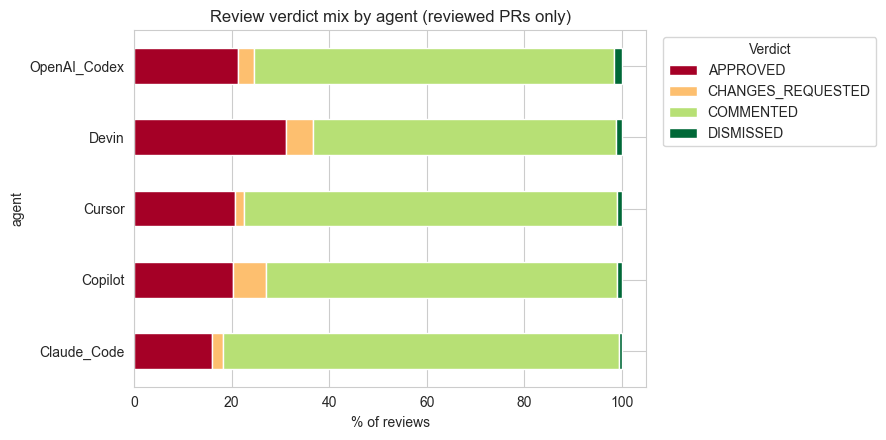

In [50]:
# RQ2a: review verdict mix, by agent (reviewed PRs only).
# Join each review to its PR's agent via pr_id -> id, then cross-tab.
if verdict_col:
    rev_agent = reviews_df[['pr_id', verdict_col]].merge(
        pr_df[['id', agent_col]], left_on='pr_id', right_on='id', how='inner'
    )
    verdict_by_agent = pd.crosstab(
        rev_agent[agent_col], rev_agent[verdict_col], normalize='index'
    ) * 100
    print("Review verdict mix by agent (% of that agent's reviews):")
    print(verdict_by_agent.round(1))

    fig, ax = plt.subplots(figsize=(9, 4.5))
    verdict_by_agent.plot(kind='barh', stacked=True, ax=ax, colormap='RdYlGn')
    ax.set_xlabel('% of reviews')
    ax.set_title('Review verdict mix by agent (reviewed PRs only)')
    ax.legend(title='Verdict', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('verdict_mix_by_agent.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('verdict_col not set — check the schema_summary output for the review state column.')

Time-to-merge (hours) by track:
                         count  mean    std  min  25%  50%   75%    90%     max
track                                                                          
Fast lane (no review)  18082.0   4.4   36.8  0.0  0.0  0.0   0.1    1.3  1249.1
Reviewed                5932.0  65.3  170.1  0.0  0.6  6.2  48.0  167.0  1797.7


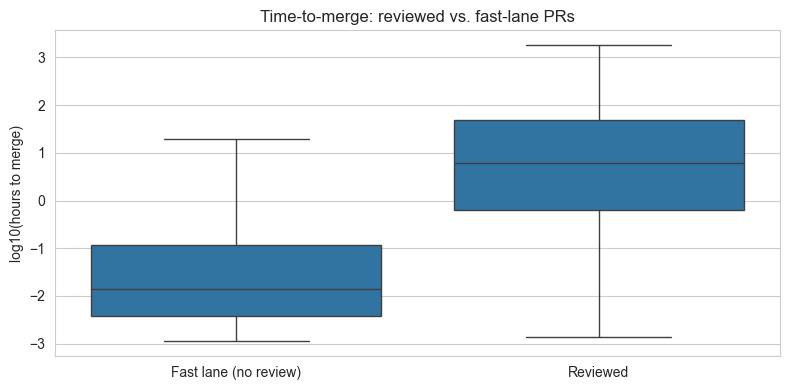

In [51]:
# RQ2b: does formal review change how long a merge takes?
# Recompute decision time on the enriched table so this cell is self-contained
# (cell 19 builds pr_enriched before the time-to-decision section runs).
for col in ['created_at', 'closed_at', 'merged_at']:
    if col in pr_enriched.columns:
        pr_enriched[col] = pd.to_datetime(pr_enriched[col], errors='coerce', utc=True)
pr_enriched['decision_hours'] = (
    pr_enriched['closed_at'].fillna(pr_enriched.get('merged_at')) - pr_enriched['created_at']
).dt.total_seconds() / 3600

# Compare merged PRs only, to hold outcome fixed.
merged = pr_enriched[(pr_enriched['outcome'] == 'merged') & (pr_enriched['decision_hours'] > 0)].copy()
merged['track'] = np.where(merged['n_reviews'] > 0, 'Reviewed', 'Fast lane (no review)')

print("Time-to-merge (hours) by track:")
print(merged.groupby('track')['decision_hours'].describe(percentiles=[.25, .5, .75, .9]).round(1))

merged['log_hours'] = np.log10(merged['decision_hours'])
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=merged, x='track', y='log_hours', ax=ax, showfliers=False)
ax.set_ylabel('log10(hours to merge)')
ax.set_xlabel('')
ax.set_title('Time-to-merge: reviewed vs. fast-lane PRs')
plt.tight_layout()
plt.savefig('time_reviewed_vs_fastlane.png', dpi=150, bbox_inches='tight')
plt.show()

### 12. Save enriched PR table

In [52]:
# Save the enriched PR table for downstream notebooks
pr_enriched.reset_index().to_parquet('pr_enriched.parquet', index=False)
print('Saved pr_enriched.parquet')

Saved pr_enriched.parquet
